# Continuous Control

---

In this notebook, you will learn how to use the Unity ML-Agents environment for the second project of the [Deep Reinforcement Learning Nanodegree](https://www.udacity.com/course/deep-reinforcement-learning-nanodegree--nd893) program.

### 1. Start the Environment

We begin by importing the necessary packages.  If the code cell below returns an error, please revisit the project instructions to double-check that you have installed [Unity ML-Agents](https://github.com/Unity-Technologies/ml-agents/blob/master/docs/Installation.md) and [NumPy](http://www.numpy.org/).

In [1]:
from unityagents import UnityEnvironment
import numpy as np

Next, we will start the environment!  **_Before running the code cell below_**, change the `file_name` parameter to match the location of the Unity environment that you downloaded.

- **Mac**: `"path/to/Reacher.app"`
- **Windows** (x86): `"path/to/Reacher_Windows_x86/Reacher.exe"`
- **Windows** (x86_64): `"path/to/Reacher_Windows_x86_64/Reacher.exe"`
- **Linux** (x86): `"path/to/Reacher_Linux/Reacher.x86"`
- **Linux** (x86_64): `"path/to/Reacher_Linux/Reacher.x86_64"`
- **Linux** (x86, headless): `"path/to/Reacher_Linux_NoVis/Reacher.x86"`
- **Linux** (x86_64, headless): `"path/to/Reacher_Linux_NoVis/Reacher.x86_64"`

For instance, if you are using a Mac, then you downloaded `Reacher.app`.  If this file is in the same folder as the notebook, then the line below should appear as follows:
```
env = UnityEnvironment(file_name="Reacher.app")
```

In [2]:
env = UnityEnvironment(file_name='Reacher_Windows_x86_64/Reacher.exe')

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_speed -> 1.0
		goal_size -> 5.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Environments contain **_brains_** which are responsible for deciding the actions of their associated agents. Here we check for the first brain available, and set it as the default brain we will be controlling from Python.

In [3]:
# get the default brain
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

### 2. Examine the State and Action Spaces

In this environment, a double-jointed arm can move to target locations. A reward of `+0.1` is provided for each step that the agent's hand is in the goal location. Thus, the goal of your agent is to maintain its position at the target location for as many time steps as possible.

The observation space consists of `33` variables corresponding to position, rotation, velocity, and angular velocities of the arm.  Each action is a vector with four numbers, corresponding to torque applicable to two joints.  Every entry in the action vector must be a number between `-1` and `1`.

Run the code cell below to print some information about the environment.

In [4]:
# reset the environment
env_info = env.reset(train_mode=True)[brain_name]

# number of agents
num_agents = len(env_info.agents)
print('Number of agents:', num_agents)

# size of each action
action_size = brain.vector_action_space_size
print('Size of each action:', action_size)

# examine the state space 
states = env_info.vector_observations
state_size = states.shape[1]
print('There are {} agents. Each observes a state with length: {}'.format(states.shape[0], state_size))
print('The state for the first agent looks like:', states[0])

Number of agents: 20
Size of each action: 4
There are 20 agents. Each observes a state with length: 33
The state for the first agent looks like: [ 0.00000000e+00 -4.00000000e+00  0.00000000e+00  1.00000000e+00
 -0.00000000e+00 -0.00000000e+00 -4.37113883e-08  0.00000000e+00
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00 -1.00000000e+01  0.00000000e+00
  1.00000000e+00 -0.00000000e+00 -0.00000000e+00 -4.37113883e-08
  0.00000000e+00  0.00000000e+00  0.00000000e+00  0.00000000e+00
  0.00000000e+00  0.00000000e+00  5.75471878e+00 -1.00000000e+00
  5.55726624e+00  0.00000000e+00  1.00000000e+00  0.00000000e+00
 -1.68164849e-01]


### 3. Take Random Actions in the Environment

In the next code cell, you will learn how to use the Python API to control the agent and receive feedback from the environment.

Once this cell is executed, you will watch the agent's performance, if it selects an action at random with each time step.  A window should pop up that allows you to observe the agent, as it moves through the environment.  

Of course, as part of the project, you'll have to change the code so that the agent is able to use its experience to gradually choose better actions when interacting with the environment!

In [ ]:
env_info = env.reset(train_mode=False)[brain_name]     # reset the environment    
states = env_info.vector_observations                  # get the current state (for each agent)
scores = np.zeros(num_agents)                          # initialize the score (for each agent)
while True:
    actions = np.random.randn(num_agents, action_size) # select an action (for each agent)
    actions = np.clip(actions, -1, 1)                  # all actions between -1 and 1
    env_info = env.step(actions)[brain_name]           # send all actions to tne environment
    next_states = env_info.vector_observations         # get next state (for each agent)
    rewards = env_info.rewards                         # get reward (for each agent)
    dones = env_info.local_done                        # see if episode finished
    scores += env_info.rewards                         # update the score (for each agent)
    states = next_states                               # roll over states to next time step
    if np.any(dones):                                  # exit loop if episode finished
        break
print('Total score (averaged over agents) this episode: {}'.format(np.mean(scores)))

When finished, you can close the environment.

In [5]:
env.close()

### 4. It's Your Turn!

Now it's your turn to train your own agent to solve the environment!  When training the environment, set `train_mode=True`, so that the line for resetting the environment looks like the following:
```python
env_info = env.reset(train_mode=True)[brain_name]
```

First Attempt with high learning rate. The learns fast but then falls into the cliff

In [ ]:
import torch
from collections import deque
import numpy as np
from unityagents import UnityEnvironment
from model import ActorCritic
from ppo_agent import PPOAgent
import matplotlib.pyplot as plt

# --- Environment setup ---
env = UnityEnvironment(file_name="Reacher_Windows_x86_64/Reacher.exe")
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

# --- Model & Agent ---
env_info = env.reset(train_mode=True)[brain_name]
state_dim = env_info.vector_observations.shape[1]
action_dim = brain.vector_action_space_size
num_agents = len(env_info.vector_observations)

print(f"Environment has {num_agents} agents, state dim: {state_dim}, action dim: {action_dim}")

model = ActorCritic(state_dim, action_dim, hidden_dim=256)
agent = PPOAgent(model, lr=3e-4, gamma=0.99, lam=0.95, eps_clip=0.1, 
                 value_coef=0.3, ent_coef=0.001)

# --- Training parameters ---
num_episodes = 2000
max_t = 1000
score_window = deque(maxlen=100)
scores = []
avg_scores = []
best_avg = -np.inf

for episode in range(1, num_episodes + 1):
    env_info = env.reset(train_mode=True)[brain_name]
    states = env_info.vector_observations           
    episode_rewards_per_agent = np.zeros(num_agents)
    done_flags = np.zeros(num_agents, dtype=bool)

    # Rollout buffers
    states_list, actions_list, log_probs_list, values_list = [], [], [], []
    rewards_list, masks_list = [], []

    for t in range(max_t):
        state_tensor = torch.tensor(states, dtype=torch.float32)  
        mean_actions, log_probs, values = [], [], []

        for s in state_tensor:
            a, log_p = model.act(s)
            mean_actions.append(a)
            log_probs.append(log_p)
            values.append(model.critic(model.forward(s)))

        actions_tensor = torch.stack(mean_actions)
        log_probs_tensor = torch.stack(log_probs)
        values_tensor = torch.stack(values)

        # Step env with all agent actions
        env_info = env.step(actions_tensor.detach().numpy())[brain_name]
        next_states = env_info.vector_observations
        rewards = np.array(env_info.rewards)
        dones = np.array(env_info.local_done)

        # Store rollout step
        states_list.append(state_tensor)
        actions_list.append(actions_tensor)
        log_probs_list.append(log_probs_tensor)
        values_list.append(values_tensor)
        rewards_list.append(torch.tensor(rewards, dtype=torch.float32))
        masks_list.append(torch.tensor(1 - dones, dtype=torch.float32))

        # Track per-agent rewards (don’t double count done agents)
        still_running = (~done_flags).astype(float)
        episode_rewards_per_agent += rewards * still_running
        done_flags |= dones

        states = next_states

        # stop early only if all agents done
        if done_flags.all():
            break

    # --- PPO Update ---
    returns = agent.compute_gae(rewards_list, masks_list, values_list)
    agent.ppo_update(states_list, actions_list, log_probs_list, returns, values_list)

    # --- Logging ---
    episode_reward = np.mean(episode_rewards_per_agent)
    score_window.append(episode_reward)
    avg_score = np.mean(score_window)
    scores.append(episode_reward)
    avg_scores.append(avg_score)

    if episode % 20 == 0:
        print(f"Episode {episode}\tReward: {episode_reward:.2f}\tAverage: {avg_score:.2f}")

        # --- Save best model ---
        if avg_score > best_avg:
            best_avg = avg_score
            torch.save({
                'episode': episode,
                'avg_score': avg_score,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
            }, f"ppo_reacher_best.pth")
            
    if len(score_window) == 100 and avg_score >= 30:
        torch.save({
                'episode': episode,
                'avg_score': avg_score,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
            }, f"ppo_reacher_solved.pth")        
        print(f"\nEnvironment solved in {episode} episodes! Model saved as 'ppo_reacher_solved.pth'.\n")
        break

# --- Plot training curve ---
plt.figure(figsize=(10, 5))
plt.plot(scores, label='Episode Reward')
plt.plot(avg_scores, label='100-episode Average', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('PPO Training Progress (20-agent Reacher)')
plt.legend()
plt.grid(True)
plt.show()


INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_speed -> 1.0
		goal_size -> 5.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Environment has 20 agents, state dim: 33, action dim: 4
Episode 20	Reward: 1.54	Average: 0.80
Episode 40	Reward: 3.35	Average: 1.50
Episode 60	Reward: 4.88	Average: 2.24
Episode 80	Reward: 8.72	Average: 3.28
Episode 100	Reward: 12.23	Average: 4.76
Episode 120	Reward: 22.11	Average: 8.14
Episode 140	Reward: 25.28	Average: 12.19
Episode 160	Reward: 27.57	Average: 16.38
Episode 180	Reward: 23.66	Average: 20.19
Episode 200	Reward: 23.15	Average: 22.96
Episode 220	Reward: 24.12	Average: 24.30
Episode 240	Reward: 26.19	Average: 25.05
Episode 260	Reward: 22.46	Average: 24.94
Episode 280	Reward: 24.30	Average: 24.59
Episode 300	Reward: 29.34	Average: 24.80
Episode 320	Reward: 28.29	Average: 25.21
Episode 340	Reward: 21.99	Average: 24.50
Episode 360	Reward: 32.25	Average: 24.14
Episode 380	Reward: 16.14	Average: 23.80
Episode 400	Reward: 26.63	Average: 23.03
Episode 420	Reward: 9.00	Average: 20.35
Episode 440	Reward: 9.29	Average: 18.18
Episode 460	Reward: 5.08	Average: 14.81
Episode 480	Reward

Train another model with lower initial learning rate

In [ ]:
import torch
from collections import deque
import numpy as np
from unityagents import UnityEnvironment
from model import ActorCritic
from ppo_agent import PPOAgent
import matplotlib.pyplot as plt

# --- Environment setup ---
env = UnityEnvironment(file_name="Reacher_Windows_x86_64/Reacher.exe")
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

# --- Model & Agent ---
env_info = env.reset(train_mode=True)[brain_name]
state_dim = env_info.vector_observations.shape[1]
action_dim = brain.vector_action_space_size
num_agents = len(env_info.vector_observations)

print(f"Environment has {num_agents} agents, state dim: {state_dim}, action dim: {action_dim}")

# --- Hiperparametreler ---
learning_rate = 1e-4   # lowered for stability
num_episodes = 1500    # more time to learn with low LR
max_t = 1000           # maximum steps per episode
gamma = 0.99
lam = 0.95
eps_clip = 0.2         
value_coef = 1.0       # boosts the Critic
ent_coef = 0.01        # Increases exploration


model = ActorCritic(state_dim, action_dim, hidden_dim=256)
agent = PPOAgent(model, lr=learning_rate, gamma=gamma, lam=lam, eps_clip=eps_clip, 
                 value_coef=value_coef, ent_coef=ent_coef)

start_factor = 1.0
end_factor = 0.01
total_iters = num_episodes

# Calculate learning rate decay per episode
def lr_lambda_func(episode):
    # Linear interpolation
    factor = start_factor - (start_factor - end_factor) * (episode / total_iters)
    # Prevent it from going below 0.01
    return max(end_factor, factor)

scheduler = torch.optim.lr_scheduler.LambdaLR(
    agent.optimizer, 
    lr_lambda=lr_lambda_func
)

# --- Training parameters ---
scores = []
avg_scores = []
score_window = deque(maxlen=100)
best_avg = -np.inf
start_episode = 1  # Sıfırdan başlıyoruz

print("Starting training from scratch...")

for episode in range(start_episode, num_episodes + 1):
    env_info = env.reset(train_mode=True)[brain_name]
    states = env_info.vector_observations         
    episode_rewards_per_agent = np.zeros(num_agents)
    done_flags = np.zeros(num_agents, dtype=bool)

    # Rollout buffers
    states_list, actions_list, log_probs_list, values_list = [], [], [], []
    rewards_list, masks_list = [], []

    for t in range(max_t):
        state_tensor = torch.tensor(states, dtype=torch.float32)

        # --- Batch Processing ---
        # Speed up action selection and value estimation
        with torch.no_grad():
            actions_tensor, log_probs_tensor = model.act(state_tensor)
            shared_features = model.forward(state_tensor)
            values_tensor = model.critic(shared_features)

        # Step env with all agent actions
        env_info = env.step(actions_tensor.detach().numpy())[brain_name]
        next_states = env_info.vector_observations
        rewards = np.array(env_info.rewards)
        dones = np.array(env_info.local_done)

        # Store rollout step
        states_list.append(state_tensor)
        actions_list.append(actions_tensor)
        log_probs_list.append(log_probs_tensor.squeeze()) 
        values_list.append(values_tensor.squeeze())      
        rewards_list.append(torch.tensor(rewards, dtype=torch.float32))
        masks_list.append(torch.tensor(1 - dones, dtype=torch.float32))

        # Track per-agent rewards
        still_running = (~done_flags).astype(float)
        episode_rewards_per_agent += rewards * still_running
        done_flags |= dones

        states = next_states

        if done_flags.all():
            break

    # --- PPO Update ---
    returns = agent.compute_gae(rewards_list, masks_list, values_list)
    agent.ppo_update(states_list, actions_list, log_probs_list, returns, values_list)

    # --- Scheduler Step ---
    scheduler.step()

    # --- Logging ---
    episode_reward = np.mean(episode_rewards_per_agent)
    score_window.append(episode_reward)
    avg_score = np.mean(score_window)
    scores.append(episode_reward)
    avg_scores.append(avg_score)

    if episode % 20 == 0:
        current_lr = agent.optimizer.param_groups[0]['lr']
        print(f"Episode {episode}\tReward: {episode_reward:.2f}\tAverage: {avg_score:.2f}\tLR: {current_lr:e}")

        # --- Save best model ---
        if avg_score > best_avg:
            best_avg = avg_score
            torch.save({
                'episode': episode,
                'avg_score': avg_score,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
            }, f"ppo_reacher_1011.pth")
            print(f"New best model saved with avg score: {best_avg:.2f}")

    if len(score_window) == 100 and avg_score >= 30:
        torch.save({
                'episode': episode,
                'avg_score': avg_score,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
            }, f"ppo_reacher_solved.pth")        
        print(f"\nEnvironment solved in {episode} episodes! Model saved as 'ppo_reacher_solved.pth'.\n")
        break

# --- Plot training curve ---
plt.figure(figsize=(10, 5))
plt.plot(scores, label='Episode Reward')
plt.plot(avg_scores, label='100-episode Average', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('PPO Training Progress (20-agent Reacher)')
plt.legend()
plt.grid(True)
plt.show()

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_speed -> 1.0
		goal_size -> 5.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Environment has 20 agents, state dim: 33, action dim: 4
Starting training from scratch...
Episode 20	Reward: 5.35	Average: 2.20	LR: 9.874600e-05
New best model saved with avg score: 2.20
Episode 40	Reward: 15.75	Average: 6.98	LR: 9.742600e-05
New best model saved with avg score: 6.98
Episode 60	Reward: 17.99	Average: 11.28	LR: 9.610600e-05
New best model saved with avg score: 11.28
Episode 80	Reward: 20.01	Average: 13.80	LR: 9.478600e-05
New best model saved with avg score: 13.80
Episode 100	Reward: 23.29	Average: 15.50	LR: 9.346600e-05
New best model saved with avg score: 15.50
Episode 120	Reward: 22.21	Average: 19.67	LR: 9.214600e-05
New best model saved with avg score: 19.67
Episode 140	Reward: 28.37	Average: 21.96	LR: 9.082600e-05
New best model saved with avg score: 21.96
Episode 160	Reward: 21.49	Average: 22.75	LR: 8.950600e-05
New best model saved with avg score: 22.75
Episode 180	Reward: 23.29	Average: 22.86	LR: 8.818600e-05
New best model saved with avg score: 22.86
Episode 20

The model could go up to 23.35. But then it stayed flat

INFO:unityagents:
'Academy' started successfully!
Unity Academy name: Academy
        Number of Brains: 1
        Number of External Brains : 1
        Lesson number : 0
        Reset Parameters :
		goal_speed -> 1.0
		goal_size -> 5.0
Unity brain name: ReacherBrain
        Number of Visual Observations (per agent): 0
        Vector Observation space type: continuous
        Vector Observation space size (per agent): 33
        Number of stacked Vector Observation: 1
        Vector Action space type: continuous
        Vector Action space size (per agent): 4
        Vector Action descriptions: , , , 


Environment has 20 agents, state dim: 33, action dim: 4
Loaded checkpoint from episode 242 (avg score: 23.40)
Continuing with new LR=1.0e-04 and high exploration (ent_coef=0.01).
Starting training from Episode 243.
Episode 243	Reward: 24.27	Average: 23.41	LR: 1.000000e-04	Ent Coef: 0.010
New best model saved with avg score: 23.41
Episode 250	Reward: 34.94	Average: 24.01	LR: 1.000000e-04	Ent Coef: 0.010
New best model saved with avg score: 24.01
Episode 260	Reward: 33.73	Average: 25.09	LR: 1.000000e-04	Ent Coef: 0.010
New best model saved with avg score: 25.09
Episode 270	Reward: 35.40	Average: 26.29	LR: 1.000000e-04	Ent Coef: 0.010
New best model saved with avg score: 26.29
Episode 280	Reward: 34.63	Average: 27.33	LR: 1.000000e-04	Ent Coef: 0.010
New best model saved with avg score: 27.33
Episode 290	Reward: 35.57	Average: 28.26	LR: 1.000000e-04	Ent Coef: 0.010
New best model saved with avg score: 28.26
Episode 300	Reward: 33.26	Average: 29.17	LR: 1.000000e-04	Ent Coef: 0.010
New best 

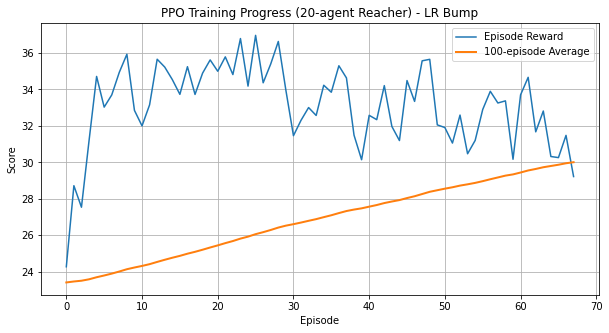

In [ ]:
import torch
from collections import deque
import numpy as np
from unityagents import UnityEnvironment
from model import ActorCritic
from ppo_agent import PPOAgent
import matplotlib.pyplot as plt

# --- Environment setup ---
env = UnityEnvironment(file_name="Reacher_Windows_x86_64/Reacher.exe")
brain_name = env.brain_names[0]
brain = env.brains[brain_name]

# --- Model & Agent Setup ---
env_info = env.reset(train_mode=True)[brain_name]
state_dim = env_info.vector_observations.shape[1]
action_dim = brain.vector_action_space_size
num_agents = len(env_info.vector_observations)

print(f"Environment has {num_agents} agents, state dim: {state_dim}, action dim: {action_dim}")

# --- Hyperparameters ---
learning_rate = 1e-4     
num_episodes = 1500
gamma = 0.99
lam = 0.8                # Reduced for stability
eps_clip = 0.2
value_coef = 1.0 
ent_coef = 0.01          # Reverted for standard exploration


model = ActorCritic(state_dim, action_dim, hidden_dim=256)
agent = PPOAgent(model, lr=learning_rate, gamma=gamma, lam=lam, eps_clip=eps_clip, 
                 value_coef=value_coef, ent_coef=ent_coef)


# --- Checkpoint Import ---
checkpoint_path = "ppo_reacher_1011.pth"
scores = []
avg_scores = []
score_window = deque(maxlen=100)
best_avg = -np.inf
start_episode = 1
max_t = 1000

try:
    checkpoint = torch.load(checkpoint_path)
    model.load_state_dict(checkpoint['model_state_dict'])
    agent.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
    
    start_episode = checkpoint['episode'] + 1
    best_avg = checkpoint['avg_score']
    
    # Assign a new learning rate
    for param_group in agent.optimizer.param_groups:
        param_group['lr'] = learning_rate
    
    print(f"Loaded checkpoint from episode {checkpoint['episode']} (avg score: {best_avg:.2f})")
    print(f"Continuing with new LR={learning_rate:.1e} and high exploration (ent_coef={agent.ent_coef}).")

    for _ in range(100):
        score_window.append(best_avg)

except FileNotFoundError:
    print(f"Checkpoint file '{checkpoint_path}' not found, starting training from Episode 1.")
    start_episode = 1
    best_avg = -np.inf


# --- LR Scheduler Devre Dışı ---
# LR will be kept constant at the manually set value.

# --- Learning Loop ---
print(f"Starting training from Episode {start_episode}.")

for episode in range(start_episode, num_episodes + 1):
    env_info = env.reset(train_mode=True)[brain_name]
    states = env_info.vector_observations
    episode_rewards_per_agent = np.zeros(num_agents)
    done_flags = np.zeros(num_agents, dtype=bool)

    # Rollout buffers
    states_list, actions_list, log_probs_list, values_list = [], [], [], []
    rewards_list, masks_list = [], []

    for t in range(max_t):
        state_tensor = torch.tensor(states, dtype=torch.float32)

        # --- Batch Processing ---
        with torch.no_grad():
            actions_tensor, log_probs_tensor = model.act(state_tensor)
            shared_features = model.forward(state_tensor)
            values_tensor = model.critic(shared_features)

        # Step env with all agent actions
        env_info = env.step(actions_tensor.detach().numpy())[brain_name]
        next_states = env_info.vector_observations
        rewards = np.array(env_info.rewards)
        dones = np.array(env_info.local_done)

        # Store rollout step
        states_list.append(state_tensor)
        actions_list.append(actions_tensor)
        log_probs_list.append(log_probs_tensor.squeeze()) 
        values_list.append(values_tensor.squeeze()) 
        rewards_list.append(torch.tensor(rewards, dtype=torch.float32))
        masks_list.append(torch.tensor(1 - dones, dtype=torch.float32))

        # Track per-agent rewards
        still_running = (~done_flags).astype(float)
        episode_rewards_per_agent += rewards * still_running
        done_flags |= dones

        states = next_states

        if done_flags.all():
            break

    # --- PPO Update ---
    returns = agent.compute_gae(rewards_list, masks_list, values_list)
    agent.ppo_update(states_list, actions_list, log_probs_list, returns, values_list)

    # --- Scheduler Step (Removed) ---
    # scheduler.step() 

    # --- Logging ---
    episode_reward = np.mean(episode_rewards_per_agent)
    score_window.append(episode_reward)
    avg_score = np.mean(score_window)
    scores.append(episode_reward)
    avg_scores.append(avg_score)
    
    if episode % 10 == 0 or episode == start_episode:
        current_lr = agent.optimizer.param_groups[0]['lr']
        print(f"Episode {episode}\tReward: {episode_reward:.2f}\tAverage: {avg_score:.2f}\tLR: {current_lr:e}\tEnt Coef: {agent.ent_coef:.3f}")

        # --- Save best model ---
        if avg_score > best_avg:
            best_avg = avg_score
            torch.save({
                'episode': episode,
                'avg_score': avg_score,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
            }, f"ppo_reacher_1011.pth")
            print(f"New best model saved with avg score: {best_avg:.2f}")

    if len(score_window) == 100 and avg_score >= 30:
        torch.save({
                'episode': episode,
                'avg_score': avg_score,
                'model_state_dict': model.state_dict(),
                'optimizer_state_dict': agent.optimizer.state_dict(),
            }, f"ppo_reacher_solved.pth")        
        print(f"\nEnvironment solved in {episode} episodes! Model saved as 'ppo_reacher_solved.pth'.\n")
        break

# --- Plot training curve ---
plt.figure(figsize=(10, 5))
plt.plot(scores, label='Episode Reward')
plt.plot(avg_scores, label='100-episode Average', linewidth=2)
plt.xlabel('Episode')
plt.ylabel('Score')
plt.title('PPO Training Progress (20-agent Reacher) - LR Bump')
plt.legend()
plt.grid(True)
plt.show()

Watch the agent

In [ ]:
import torch
import numpy as np
from unityagents import UnityEnvironment
from model import ActorCritic

# --- Environment and Variable Setup ---
# env, brain_name, num_agents are assumed to be defined globally.
num_agents = 20 
action_dim = 4

# --- Checkpoint and Model Preparation ---
checkpoint_path = 'ppo_reacher_solved.pth'
state_dim = 33 

model = ActorCritic(state_dim, action_dim, hidden_dim=256) 
checkpoint = torch.load(checkpoint_path, map_location='cpu')
model.load_state_dict(checkpoint['model_state_dict'])

model.eval()

# --- Evaluation Loop ---
n_episodes = 3 

for ep in range(1, n_episodes + 1):
    env_info = env.reset(train_mode=False)[brain_name] 
    states = env_info.vector_observations 
    scores = np.zeros(num_agents) 
    
    print(f"\n--- Episode {ep} Started ---")

    while True:
        states_t = torch.tensor(states, dtype=torch.float32) 
        
        with torch.no_grad():
            mean, _ = model.act(states_t) 
            actions_reshaped = mean.cpu().numpy()
        
        env_info = env.step({brain_name: actions_reshaped})[brain_name] 

        next_states = env_info.vector_observations 
        rewards = env_info.rewards 
        dones = env_info.local_done 
        
        scores += rewards 
        states = next_states
        
        if np.any(dones):
            break
            
    print('Episode {} Total score (averaged over agents): {:.2f}'.format(ep, np.mean(scores)))

# Close environment
# env.close()


--- Episode 1 Started ---
Episode 1 Total score (averaged over agents): 34.18

--- Episode 2 Started ---


In [ ]:
env.close()